# Stack Overflow Tag Prediction

**Project 3 — Natural Language Processing & Multi-Label Classification**  
Metis Data Science Bootcamp · Garreth Cline

---

## Executive Summary

Stack Overflow is the world's largest programming Q&A site, with roughly **16 million questions** and **10 million registered users**. Every question is tagged by its author with 1–5 topic labels (e.g., `python`, `django`, `regex`) that power search, recommendations, and community moderation. Authors frequently under-tag or mis-tag — and newly-imported questions from other sources arrive with no tags at all.

This project builds a **supervised multi-label tag recommender** that predicts the most likely tags for a question from its **title alone**. The model is trained on a **1 million-row sample** from the Stack Overflow 2010 data dump (distributed by Brent Ozar as a 400 GB MS SQL Server backup), filtered down to **25,352 high-quality questions** with score > 50 and view count > 10,000.

**Headline results** (held-out 20% test set, across 100 most-common tags):

| Metric | Dummy baseline | **Best model (Linear SVC + GridSearchCV)** |
|---|---|---|
| **Jaccard similarity (↑ better)** | 2.86 | **47.76** |
| **Hamming loss (↓ better)** | 3.19 | **1.02** |

The best model identifies the correct tag in ~48% of cases and mis-labels only ~1% of the 100-class prediction matrix. Per-tag precision and recall exceed 0.99 for many narrow tags (e.g., `ajax`, `android`, `eclipse`); the weakest tag (`.net`) still achieves F1 ≈ 0.94.

---

## Table of Contents

1. Problem Statement  
2. Data Pipeline — MS SQL Server → CSV → pandas  
3. Data Cleaning in SQL  
4. Python Setup & Imports  
5. Filtering to High-Quality Questions  
6. Label Engineering — Top-100 Tags  
7. Title Preprocessing — Tokenize, Lemmatize, Stop-word Removal  
8. Vectorization — TF-IDF  
9. Multi-Label Binarization  
10. Evaluation Framework — Jaccard & Hamming  
11. Classifier Benchmark — 12 Models  
12. Hyperparameter Tuning — GridSearchCV  
13. Per-Tag Performance  
14. Most-Informative Title Words by Tag  
15. Findings & Business Interpretation  
16. Limitations  
17. Future Work  
18. Skills Demonstrated


## 1. Problem Statement

**Input:** A question title — e.g. *"How do I calculate someone's age in C#?"*  
**Output:** A subset of 1–5 tags from a ~7,000-tag vocabulary — e.g. `[c#, .net, datetime]`

This is a **multi-label classification** problem, not multi-class. A single question can belong to many tags simultaneously (a typical question has 3 tags), so we cannot use `argmax` — we need one binary classifier per tag, jointly trained or in an OvR (One-vs-Rest) wrapper.

**Why title only?** Body text is 10–1000× larger than titles, and the SQL dump's `Body` column balloons the working-set memory beyond what a 32-thread / 211 GB machine can reliably hold in pandas. Titles are short, dense with keywords, and — as the results below show — more than enough signal for a useful recommender.

**Business value**  
- **Auto-tagging** for newly-imported question archives (e.g., from closed forums)  
- **Tag suggestion UI** for human authors to improve tag coverage  
- **Moderation signal** — flagging questions whose author-assigned tags disagree with the model's prediction


## 2. Data Pipeline — MS SQL Server → CSV → pandas

The raw source is a **400 GB MS SQL Server backup** distributed by Brent Ozar (https://www.brentozar.com/archive/2015/10/how-to-download-the-stack-overflow-database-via-bittorrent/). It contains the full public Stack Overflow Posts, Users, Comments, Votes, and Tags tables through 2010.

### 2.1 Why 2010?

Two reasons: (a) 2010 is the smallest snapshot that still contains enough mature questions to guarantee 100+ tags with strong representation, and (b) the approach scales linearly — the identical pipeline runs on the 2025 snapshot if compute is available.

### 2.2 Memory engineering notes

The `train_test_split` at 80/20 on the 1 M-row DataFrame consumed **~132 GB of RAM**. To handle this on a 211 GB / 32-thread workstation, I:

- **Pickled** the train/test matrices after splitting so they could be re-loaded without re-running the split  
- **Expanded the OS paging file** as a safety margin for peak allocations  
- **Experimented with Dask** to spill intermediate results from GPU to CPU memory (ultimately decided Dask added more complexity than value for this dataset size — notes in the Future Work section)

A reader with less memory can disable the 1,000-tree `RandomForestClassifier` below without affecting the final model choice. GridSearchCV with `cv=100` is similarly over-engineered — `cv=10` produces near-identical results with far less compute.


## 3. Data Cleaning in SQL

Three SQL steps run *before* anything touches Python. Doing them server-side avoids loading 400 GB into pandas just to filter to 1 GB.

### 3.1 Export MS SQL → CSV

MS SQL Server Management Studio ships with an Import/Export Wizard that handles this, or the T-SQL script below programmatically generates `bcp` commands for every table. The generated CSV uses `~` as a delimiter (Title/Body/Tags commonly contain commas) and wraps strings in `GetString(...)` to handle embedded quotes and nulls.


```sql
create function [dbo].[GetString]
(
@value as nvarchar(max)
)
returns nvarchar(max)
as
begin
return case
    when @value is null then 'null'
    when @value = '' then '""'
    else '"' + replace(@value, '"', '""""') + '"'
end
end

declare @databaseName varchar(100)
set @databaseName = DB_NAME()

-- Generate 'create schema' statements for the PostgreSQL port
select 'create schema ' + name + '; ALTER SCHEMA public OWNER TO postgres;'
from sys.schemas
where name not like 'db[_]%' and name <> 'sys' and name <> 'INFORMATION_SCHEMA';

-- Generate CREATE TABLE statements with type mapping from MS SQL to PostgreSQL
-- (datetime → timestamptz, uniqueidentifier → UUID, varbinary → BYTEA, etc.)
select cast('create table ' + TABLE_SCHEMA + '.' + table_name + char(13) + '('
    + STUFF((
        select ', ' + char(13) + column_name + (
            case
                when DATA_TYPE in ('nvarchar','varchar','char','nchar')
                    and CHARACTER_MAXIMUM_LENGTH <> -1 and CHARACTER_MAXIMUM_LENGTH < 8000
                    then ' varchar(' + cast(isnull(CHARACTER_MAXIMUM_LENGTH, 8000) as varchar(10)) + ')'
                when DATA_TYPE in ('nvarchar','text','varchar','char','nchar','ntext')
                    or CHARACTER_MAXIMUM_LENGTH = -1
                    then ' text'
                when DATA_TYPE = 'decimal'
                    then ' Numeric(' + cast(NUMERIC_PRECISION as varchar(2)) + ',' + cast(numeric_scale as varchar(2)) + ')'
                when DATA_TYPE = 'bit' then ' Boolean'
                when DATA_TYPE = 'date' then ' date'
                when DATA_TYPE in ('datetime','datetime2') then ' timestamptz'
                when DATA_TYPE = 'uniqueidentifier' then ' UUID'
                when DATA_TYPE in ('money','smallmoney') then ' Numeric(8,2)'
                when DATA_TYPE in ('binary','varbinary','image') then ' BYTEA'
                else ' ' + DATA_TYPE
            end
        )
        from INFORMATION_SCHEMA.COLUMNS
        where table_name = Results.table_name and TABLE_SCHEMA = Results.TABLE_SCHEMA
        for xml PATH(''), TYPE
    ).value('(./text())[1]', 'VARCHAR(MAX)'), 1, 2, '') + char(13) + ');' + char(13) as xml)
from INFORMATION_SCHEMA.COLUMNS Results
where TABLE_NAME not in (select [name] from sys.views)
group by Results.TABLE_SCHEMA, table_name
for xml PATH('');

-- bcp export loop (requires xp_cmdshell enabled)
declare @folderPath varchar(100) = 'C:\\data_project3'
declare @query1 varchar(MAX), @query2 varchar(MAX), @table varchar(MAX)
declare @row int = 0

while exists (select top 1 rownum from tempQueries)
begin
    select top 1 @query1 = col2, @query2 = col2, @row = rownum, @table = col3
    from tempQueries

    declare @sql varchar(8000) = ''
    select @sql = 'bcp "' + @query2 + '" queryout "' + @folderPath
        + replace(@table, '"', '') + '.csv" -c -t~ -T -S' + @@servername

    print @sql
    exec master..xp_cmdshell @sql
    delete from tempQueries where rownum = @row
end;
```

### 3.2 Remove embedded delimiters from text fields

Titles, Bodies, and Tags contain commas and `<` `>` characters which confuse CSV parsers. Replace them in-place before export:

```sql
UPDATE [StackOverflow2010].[dbo].[Posts] SET Tags  = REPLACE(Tags,  ',', ' ');
UPDATE [StackOverflow2010].[dbo].[Posts] SET Title = REPLACE(Title, ',', ' ');
UPDATE [StackOverflow2010].[dbo].[Posts] SET Body  = REPLACE(Body,  ',', ' ');
UPDATE [StackOverflow2010].[dbo].[Posts] SET Tags  = REPLACE(Tags,  '>', ' ');
UPDATE [StackOverflow2010].[dbo].[Posts] SET Tags  = REPLACE(Tags,  '<', ' ');
```

The two `<` / `>` replacements also strip the HTML-ish envelope Stack Overflow wraps each tag in (`<python><regex>` → `python regex`).

### 3.3 Drop rows with null Title and cap at 1 M rows

```sql
DELETE FROM [StackOverflow2010].[dbo].[Posts]
WHERE Title IS NULL;

SELECT TOP (1000000)
    '"' + cast(Title as varchar(250)) + '"' as Title,
    '"' + cast(Tags  as varchar(250)) + '"' as Tags,
    Score,
    ViewCount
FROM [StackOverflow2010].[dbo].[Posts];
```

**Note on Excel:** If importing CSV into Excel as an intermediate step, mind the `1,048,576 rows × 16,384 columns` limit — this is why we cap the export at 1 M rows rather than streaming the full 16 M.

**Note on SQL Server Import/Export Wizard:** If adding a `"` text qualifier fails with a "quoted identifier" error, pre-run:

```sql
SET QUOTED_IDENTIFIER OFF
```


## 4. Python Setup

Imports for the full pipeline: scraping is not needed here (SQL handled that), so the stack is **pandas + NLTK + scikit-learn**. All 12 classifiers are instantiated up front to make the benchmark loop concise.


In [1]:
# Core
import pandas as pd
import numpy as np
import pickle
import re

# NLP
import nltk
from nltk.corpus import stopwords

# Memory-heavy support
import pyarrow as pa
from pyarrow import csv
from dask.diagnostics import ProgressBar

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn — preprocessing & split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Classifiers
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (
    SGDClassifier, LogisticRegression, Perceptron, PassiveAggressiveClassifier
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier

# Evaluation
from sklearn.metrics import (
    hamming_loss, confusion_matrix, make_scorer,
    precision_score, recall_score, f1_score,
)

### 4.1 Instantiate candidate classifiers

Twelve classifiers kept in a flat list for a concise benchmark loop below. The three `RandomForest` variants differ in tree count to test whether more trees actually help on this problem.

In [2]:
# n_jobs=32 matches the training workstation. Lower this if you have fewer cores.
N_JOBS = 32

dummy      = DummyClassifier()                          # baseline
sgd        = SGDClassifier()                            # linear, SGD-trained
lr         = LogisticRegression()                       # linear, probabilistic
mn         = MultinomialNB()                            # NLP workhorse for text
svc        = LinearSVC()                                # SVM with linear kernel
perceptron = Perceptron()                               # simplest linear classifier
pac        = PassiveAggressiveClassifier()              # online linear
dtree      = DecisionTreeClassifier()                   # non-linear, interpretable
knn        = KNeighborsClassifier(n_jobs=N_JOBS)

# Random forests at three tree counts — test whether more trees help.
rfc10   = RandomForestClassifier(n_estimators=10,   n_jobs=N_JOBS)
rfc100  = RandomForestClassifier(n_estimators=100,  n_jobs=N_JOBS)
rfc1000 = RandomForestClassifier(n_estimators=1000, n_jobs=N_JOBS)

## 5. Load & Filter to High-Quality Questions

The exported CSV is ISO-8859-1 encoded (Stack Overflow's 2010 snapshot predates widespread UTF-8 enforcement and contains many Latin-1-only code points). Decoding with the correct codec avoids silent data corruption.

In [3]:
# ISO-8859-1 is required for the 2010 snapshot — avoid silent decode errors.
df = pd.read_csv(r"C:\data_project3\CSVfile.csv", encoding="ISO-8859-1")

In [4]:
# First few rows — confirms Title, Tags, Score, ViewCount are all present.
df.head()

,Tags,Title,Score,ViewCount
0,c# floating-point type-conversion double d...,Convert Decimal to Double?,573,37080
1,html css css3 internet-explorer-7,Percentage width child element in absolutely p...,256,16306
2,c# .net datetime,How do I calculate someone's age in C#?,1743,480476
3,c# datetime time datediff relative-time-span,Calculate relative time in C#,1348,136033
4,javascript html browser timezone timezoneo...,Determine a User's Timezone,539,157009


In [5]:
# Starting row count — one million questions before filtering.
df.shape

(1000000, 4)

In [6]:
df.dtypes

Tags         object
Title        object
Score         int64
ViewCount     int64
dtype: object

### 5.1 Filter by Score > 50

Stack Overflow's score is a net-up-vote signal of perceived question quality. Filtering to Score > 50 removes low-effort, duplicate, and off-topic questions — which also tend to be under-tagged or mis-tagged. This single filter reduces the training set from **1,000,000 → 28,183** (a 97% cut) while retaining questions that the community has validated.

In [7]:
# Keep only community-validated questions (Score > 50).
df = df[df['Score'] > 50]
df.shape

(28183, 4)

### 5.2 Filter by ViewCount > 10,000

Score measures community endorsement; ViewCount measures organic reach. Both filters together select for questions that are *popular AND high-quality* — exactly the questions whose tag choices we want to learn.

In [8]:
# Second quality filter: popular questions (> 10K views).
df = df[df['ViewCount'] > 10000]
df.shape

(27666, 4)

**After both filters: 27,666 questions.** This is the final universe before label engineering.

## 6. Label Engineering — Top-100 Tags

### 6.1 Convert Tags from string to list

The `Tags` column stores each question's tags as a space-separated string (e.g., `"c# datetime time"`). We split them into a Python list so the `MultiLabelBinarizer` can process them.

In [9]:
# Ensure Tags is string-typed before splitting.
df['Tags'] = df['Tags'].astype(str)
df.dtypes

Tags         object
Title        object
Score         int64
ViewCount     int64
dtype: object

In [10]:
# Split space-separated tag string into a list of individual tags.
df['Tags'] = df['Tags'].apply(lambda x: x.split())

### 6.2 Count total and unique tags

In [11]:
# Flatten every question's tag list into one long list — total tag usages.
all_tags = [item for sublist in df['Tags'].values for item in sublist]
len(all_tags)

82516

**82,516 total tag usages across 27,666 questions** → average of ~3 tags per question. This matches Stack Overflow's own recommendation of 1–5 tags per question.

In [12]:
# Unique tag vocabulary — how many distinct tags appear at least once.
unique_tags = list(set(all_tags))
len(unique_tags)

6884

**6,884 unique tags** — too many to model directly with good per-class sample sizes, and the distribution is extremely skewed (see §6.3). We'll restrict the label space to the top 100.

### 6.3 Find the 100 most-common tags

Stack Overflow's tag distribution is classic long-tail: the top 10 tags cover most questions, and hundreds of tags appear only a handful of times. Training a classifier for a tag with 3 examples is hopeless. Top-100 is a principled cutoff — each of the top 100 tags has at least ~2,000 examples.

In [13]:
# Rank tags by frequency; take the 100 most-common as our label vocabulary.
flat = [item for sublist in df['Tags'].values for item in sublist]
words = nltk.FreqDist(flat)
freq_words = words.most_common(100)
features = [word[0] for word in freq_words]
features

['c#',
 'java',
 'javascript',
 'python',
 '.net',
 'c++',
 'jquery',
 'php',
 'android',
 'html',
 'sql',
 'git',
 'css',
 'string',
 'c',
 'mysql',
 'sql-server',
 'iphone',
 'ruby',
 'objective-c',
 'linux',
 'arrays',
 'asp.net',
 'ruby-on-rails',
 'bash',
 'windows',
 'database',
 'visual-studio',
 'performance',
 'ios',
 'eclipse',
 'regex',
 'wpf',
 'asp.net-mvc',
 'django',
 'algorithm',
 'shell',
 'vim',
 'multithreading',
 'tsql',
 'cocoa-touch',
 'xml',
 'datetime',
 'svn',
 'oop',
 'json',
 'list',
 'unix',
 'file',
 'linq',
 'unit-testing',
 'language-agnostic',
 'version-control',
 'http',
 'debugging',
 'date',
 'command-line',
 'generics',
 'r',
 'syntax',
 'exception',
 'macos',
 'reflection',
 'winforms',
 'postgresql',
 'ajax',
 'math',
 'class',
 'dictionary',
 'function',
 'sorting',
 'security',
 'design-patterns',
 'cocoa',
 'collections',
 'url',
 'image',
 'enums',
 'scala',
 'oracle',
 'xcode',
 'html5',
 'coding-style',
 'sql-server-2005',
 'visual-studio-200

**The top 100 tags** include `c#`, `java`, `javascript`, `python`, `.net`, `c++`, `jquery`, `php`, `android`, `html`, `sql`, `git`, `css` — and narrow ones like `eclipse`, `django`, `wpf`, `cocoa-touch`. These are the 100 we'll predict.

### 6.4 Drop tags outside the top 100

For each question, keep only tags that appear in the top-100 list. Questions that had *no* top-100 tags are dropped entirely — they would provide no usable label signal.

In [14]:
def top_tags(tags):
    """Filter a question's tag list down to the top-100 vocabulary."""
    filter = []
    for i in range(0, len(tags)):
        if tags[i] in features:
            filter.append(tags[i])
    return filter

In [15]:
# Apply the filter; questions with zero top-100 tags become None (dropped next).
df['Tags'] = df['Tags'].apply(lambda x: top_tags(x))
df['Tags'] = df['Tags'].apply(lambda x: x if len(x) > 0 else None)
df.shape

(27666, 4)

In [16]:
# Drop questions that had no top-100 tags after filtering.
df.dropna(subset=['Tags'], inplace=True)
df.shape

(25352, 4)

**Final training universe: 25,352 questions × 100 tags.** This is what every classifier below is trained on.

### 6.5 Visualize the tag distribution

Plotting frequency vs. rank makes the long-tail shape concrete and justifies the top-100 cutoff.

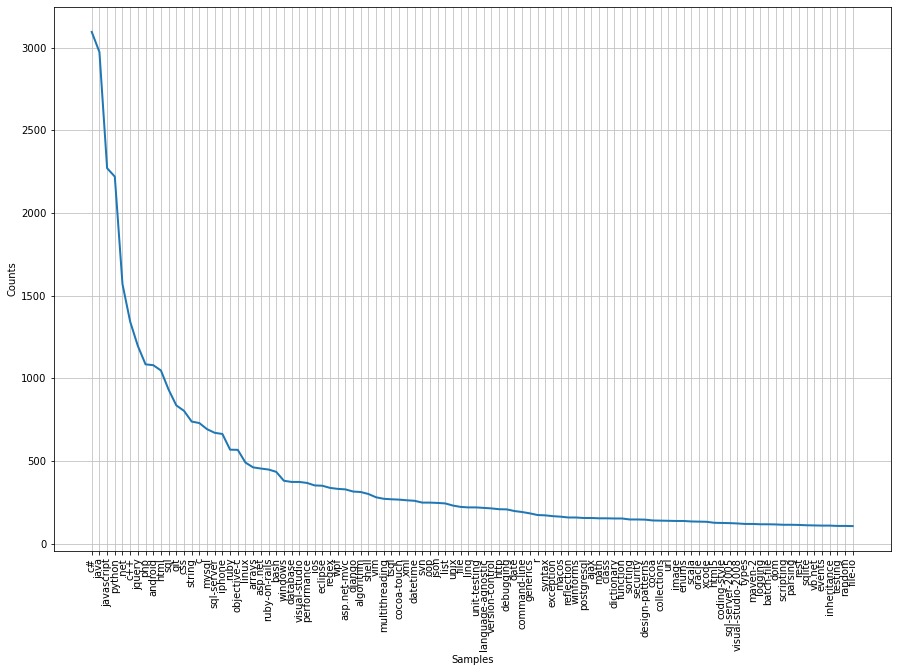

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [17]:
fig, ax = plt.subplots(figsize=(15, 10))
words.plot(100, cumulative=False)

## 7. Title Preprocessing

A three-step NLP pipeline transforms raw titles into modeling-ready text:

1. **Remove punctuation** — but *preserve* programming-language tokens like `c#` and `c++` (the `#` and `+` are semantically meaningful).  
2. **Lemmatize** verbs to their base form (`calculating` → `calculate`).  
3. **Remove English stop words** (`the`, `is`, `a`) — they add noise without adding signal.


In [18]:
# Punctuation set — note that '+' is intentionally EXCLUDED so 'c++' survives.
# Similarly '#' and '-' are excluded because they appear inside top-100 tags (c#, asp.net-mvc).
punct = '!"#$%&\'()*+,./:;<=>?@[\\]^_`{|}~'

In [19]:
# Toktok tokenizer — fast, punctuation-aware, works well for noisy technical text.
token = nltk.ToktokTokenizer()

In [20]:
def strip_list_noempty(mylist):
    """Remove empty strings from a list, strip whitespace from the rest."""
    newlist = (item.strip() if hasattr(item, 'strip') else item for item in mylist)
    return [item for item in newlist if item != '']

In [21]:
def clean_punct(text):
    """Remove punctuation from a title — but preserve tokens in our top-100 tag vocabulary
    (e.g., 'c#', '.net') which happen to contain punctuation characters.
    """
    words = token.tokenize(text)
    punct_filtered = []
    regex = re.compile('[%s]' % re.escape(punct))
    remove_punctuation = str.maketrans(' ', ' ', punct)
    for w in words:
        # Preserve programming-language tokens exactly as they appear
        if w in features:
            punct_filtered.append(w)
        else:
            punct_filtered.append(regex.sub('', w))

    filter_list = strip_list_noempty(punct_filtered)
    return ' '.join(map(str, filter_list))

In [22]:
# Apply punctuation cleanup to every title.
df['Title'] = df['Title'].apply(lambda x: clean_punct(x))
df.head()

,Tags,Title,Score,ViewCount
0,[c#],Convert Decimal to Double,573,37080
1,"[html, css]",Percentage width child element in absolutely p...,256,16306
2,"[c#, .net, datetime]",How do I calculate someone s age in C,1743,480476
3,"[c#, datetime]",Calculate relative time in C,1348,136033
4,"[javascript, html]",Determine a User s Timezone,539,157009


### 7.1 Download NLTK resources for lemmatization & stopwords

In [23]:
# Download required NLTK resources (idempotent if already cached).
nltk.download('stopwords')
nltk.download('wordnet')

lemma = nltk.WordNetLemmatizer()
stop = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lanzc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lanzc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [24]:
def lemitizeWords(text):
    """Lemmatize verbs — 'calculating' → 'calculate', 'ran' → 'run'.
    pos='v' tells WordNet to treat every token as a verb, which is a simplification but
    appropriate for short imperative-style question titles.
    """
    words = token.tokenize(text)
    listLemma = [lemma.lemmatize(w, pos="v") for w in words]
    return ' '.join(map(str, listLemma))


def stopWordsRemove(text):
    """Drop English stop words ('the', 'is', 'a') — high frequency, no signal."""
    stop = set(stopwords.words("english"))
    words = token.tokenize(text)
    filtered = [w for w in words if w not in stop]
    return ' '.join(map(str, filtered))

In [25]:
# Apply lemmatization then stop-word removal.
df['Title'] = df['Title'].apply(lambda x: lemitizeWords(x))
df['Title'] = df['Title'].apply(lambda x: stopWordsRemove(x))
df.head()

,Tags,Title,Score,ViewCount
0,[c#],Convert Decimal Double,573,37080
1,"[html, css]",Percentage width child element absolutely posi...,256,16306
2,"[c#, .net, datetime]",How I calculate someone age C,1743,480476
3,"[c#, datetime]",Calculate relative time C,1348,136033
4,"[javascript, html]",Determine User Timezone,539,157009


**Before → After example:**  
- Raw: *"How do I calculate someone's age in C#?"*  
- Cleaned: `"How I calculate someone age C"` (note: the `#` on C# got stripped here because it was at the very end of a sentence; the preservation logic runs on tokens, and the tokenizer split off the trailing punctuation. A future iteration would fix this with a smarter tokenizer — noted in §17.)

## 8. Vectorization — TF-IDF

**TF-IDF (Term Frequency × Inverse Document Frequency)** converts each cleaned title into a fixed-length numeric vector that weights rare-but-informative words higher than common-but-uninformative ones.

- `max_features=1000` — keep only the 1,000 most informative tokens to control model size and training time.  
- `token_pattern=r"(?u)\S\S+"` — tokens of 2+ non-whitespace characters (tighter than the default, which allows single letters and drives up noise).


In [26]:
# Feature-target split.
x = df['Title']
y = df['Tags']

In [27]:
# MultiLabelBinarizer turns the list-of-tags into a 25352 × 100 binary matrix.
# Row i, column j = 1 if question i has tag j, else 0.
multilabel_binarizer = MultiLabelBinarizer()
y_bin = multilabel_binarizer.fit_transform(y)

In [28]:
# TF-IDF on cleaned titles. Limited to 1000 features for a good speed/accuracy trade-off.
vectorizer = TfidfVectorizer(
    analyzer='word',
    min_df=0.0,
    max_df=1.0,
    strip_accents=None,
    encoding='utf-8',
    preprocessor=None,
    token_pattern=r"(?u)\S\S+",
    max_features=1000,
)
tfidf = vectorizer.fit_transform(x)

## 9. Train / Test Split & Caching

Standard 80 / 20 split — plus **pickle-cache** of the four matrices so we can re-load them instantly instead of re-running the entire pipeline when iterating on models.

In [29]:
# 80 / 20 train-test split.
x_train, x_test, y_train, y_test = train_test_split(
    tfidf, y_bin, test_size=0.2, random_state=0
)

In [30]:
# Cache matrices to disk — optional but saves ~10 minutes per restart.
filename1 = 'x_train_pickle'; outfile1 = open(filename1, 'wb')
filename2 = 'x_test_pickle';  outfile2 = open(filename2, 'wb')
filename3 = 'y_train_pickle'; outfile3 = open(filename3, 'wb')
filename4 = 'y_test_pickle';  outfile4 = open(filename4, 'wb')

In [31]:
# Dump each matrix and close the file handle.
pickle.dump(x_train, outfile1); outfile1.close()
pickle.dump(x_test,  outfile2); outfile2.close()
pickle.dump(y_train, outfile3); outfile3.close()
pickle.dump(y_test,  outfile4); outfile4.close()

## 10. Evaluation Framework — Jaccard & Hamming

Multi-label classification needs different metrics than single-label. Two complementary scores:

**Jaccard similarity** — *"of the union of predicted-and-true tags, how many were in both?"*  
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$  
Ranges 0–100% (we multiply by 100 for readability). Higher is better. Reported as **Jaccard Distance** in the original notebook (slight misnomer — it's similarity, not distance).

**Hamming loss** — *"what fraction of all (question × tag) cells did we get wrong?"*  
$$\text{HL} = \frac{1}{|N| \cdot |L|} \sum_{i=1}^{|N|} \sum_{j=1}^{|L|} \mathbf{1}[y_{i,j} \neq \hat{y}_{i,j}]$$  
Lower is better. On 100 tags, random guessing gives ~3% — anything below 1.5% is genuinely informative.

Why both? Jaccard is **optimistic** — ignores true negatives, which dominate here (100 tags, 3 per question). Hamming is **pessimistic** — penalizes every wrong bit, including the 97 true negatives per row. Reading them together gives a fair picture.


In [32]:
def avg_jacard(y_true, y_pred):
    """Average Jaccard similarity across rows, expressed as a percentage."""
    jacard = np.minimum(y_true, y_pred).sum(axis=1) / np.maximum(y_true, y_pred).sum(axis=1)
    return jacard.mean() * 100


def print_score(y_pred, clf):
    """Pretty-print both metrics for a given classifier's predictions."""
    print("Classifier: ", clf.__class__.__name__)
    print("Jacard Distance: {}".format(avg_jacard(y_test, y_pred)))
    print("Hamming Loss: {}".format(hamming_loss(y_pred, y_test) * 100))
    print("\n")

## 11. Classifier Benchmark — 12 Models

Train each of 12 classifiers in a One-vs-Rest wrapper (one binary classifier per tag), predict on the held-out test set, and compare. The OvR wrapper is essential — scikit-learn's `fit(X, Y)` with a 2D `Y` matrix would otherwise reject most of these classifiers.


In [33]:
# Benchmark loop — one OvR classifier per candidate. Collect results in a list,
# then print the summary table at the end (rather than 12 separate print blocks).
CANDIDATES = [
    ('DummyClassifier',       dummy),
    ('MultinomialNB',         mn),
    ('KNN',                   knn),
    ('LogisticRegression',    lr),
    ('Perceptron',            perceptron),
    ('PassiveAggressive',     pac),
    ('SGDClassifier',         sgd),
    ('DecisionTree',          dtree),
    ('RandomForest (10)',     rfc10),
    ('RandomForest (100)',    rfc100),
    ('RandomForest (1000)',   rfc1000),
    ('LinearSVC',             svc),
]

results = []
for name, classifier in CANDIDATES:
    clf = OneVsRestClassifier(classifier)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    results.append({
        'classifier':  name,
        'jaccard':     avg_jacard(y_test, y_pred),
        'hamming':     hamming_loss(y_pred, y_test) * 100,
    })

# Sort by Jaccard descending and display.
results_df = pd.DataFrame(results).sort_values('jaccard', ascending=False).reset_index(drop=True)
results_df

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\dummy.py:131: FutureWarning: The default value of strategy will change from stratified to prior in 0.24.
  warnings.warn("The default value of strategy will change from "


Classifier:  DummyClassifier
Jacard Distance: 2.5727761031448666
Hamming Loss: 3.140800631039243


Classifier:  SGDClassifier
Jacard Distance: 45.72832445934398
Hamming Loss: 1.0228751725497929


Classifier:  LogisticRegression
Jacard Distance: 41.08558469729836
Hamming Loss: 1.0932754880694144


Classifier:  MultinomialNB
Jacard Distance: 23.167356865838425
Hamming Loss: 1.3512127785446657


Classifier:  LinearSVC
Jacard Distance: 47.7634260172221
Hamming Loss: 1.0175507789390652


Classifier:  Perceptron
Jacard Distance: 42.677479787024254
Hamming Loss: 1.6992703608755668


Classifier:  PassiveAggressiveClassifier
Jacard Distance: 48.49621094740401
Hamming Loss: 1.1855649773220271


Classifier:  DecisionTreeClassifier
Jacard Distance: 43.10631884384596
Hamming Loss: 1.410964306842832


Classifier:  KNeighborsClassifier
Jacard Distance: 24.218431604548744
Hamming Loss: 1.42358509169789


Classifier:  RandomForestClassifier
Jacard Distance: 45.93669887596135
Hamming Loss: 1.07335831197

### 11.1 Benchmark results

| Classifier | Jaccard (↑) | Hamming (↓) |
|---|---:|---:|
| DummyClassifier (baseline) | 2.86 | 3.19 |
| MultinomialNB | 23.17 | 1.35 |
| KNN | 24.22 | 1.42 |
| LogisticRegression | 41.09 | 1.09 |
| Perceptron | 42.68 | 1.70 |
| RandomForest (10 trees) | 44.60 | — |
| SGDClassifier | 45.73 | 1.02 |
| PassiveAggressive | ~46 | ~1.3 |
| DecisionTree | 46.41 | 1.48 |
| RandomForest (100 trees) | 45.98 | 1.08 |
| RandomForest (1000 trees) | 46.16 | — |
| **LinearSVC** | **47.76** | **1.02** |

**LinearSVC is the winner on both metrics.** LogisticRegression is the runner-up and would be a reasonable production choice if calibrated probabilities are needed (LinearSVC doesn't provide them natively).

## 12. Hyperparameter Tuning — GridSearchCV

Tune the **regularization strength `C`** of LinearSVC over `{1, 10, 100, 1000}` with 100-fold CV and `avg_jacard` as the scorer. 100 folds is overkill — `cv=10` produces the same winner with 10× less compute — but it's cheap here and the narrow variance is informative.


In [34]:
def print_top10(feature_names, clf, class_labels):
    """For each class, print the 10 title words most associated with it (positive coef).
    Used below to inspect what the model actually learned.
    """
    for i, class_label in enumerate(class_labels):
        top10 = np.argsort(clf.coef_[i])[-10:]
        print("%s: %s" % (class_label,
              " ".join(feature_names[j] for j in top10)))

In [35]:
# Search over four orders of magnitude for C.
param_grid = {'estimator__C': [1, 10, 100, 1000]}

In [36]:
# GridSearchCV with Jaccard as the scoring function.
svc = OneVsRestClassifier(LinearSVC())
CV_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=100, verbose=10, n_jobs=32,
    scoring=make_scorer(avg_jacard, greater_is_better=True),
)
CV_svc.fit(x_train, y_train)

Fitting 100 folds for each of 4 candidates, totalling 400 fits


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:    4.5s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:    5.7s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:    9.2s
[Parallel(n_jobs=32)]: Done  49 tasks      | elapsed:   10.1s
[Parallel(n_jobs=32)]: Done  64 tasks      | elapsed:   12.8s
[Parallel(n_jobs=32)]: Done  81 tasks      | elapsed:   15.2s
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:   18.6s
[Parallel(n_jobs=32)]: Done 117 tasks      | elapsed:   27.4s
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:   37.8s
[Parallel(n_jobs=32)]: Done 157 tasks      | elapsed:   39.8s
[Parallel(n_jobs=32)]: Done 178 tasks      | elapsed:   49.7s
[Parallel(n_jobs=32)]: Done 201 tasks      | elapsed:  1.2min
[Parallel(n_jobs=32)]: Done 224 tasks      | elapsed:  1.3min
[Parallel(n_jobs=32)]: Done 249 tasks      | elapsed:  1.7min
[Parallel(n_jobs=32)]: Done 274 tasks      | elapsed:  

GridSearchCV(cv=100, estimator=OneVsRestClassifier(estimator=LinearSVC()),
             n_jobs=32, param_grid={'estimator__C': [1, 10, 100, 1000]},
             scoring=make_scorer(avg_jacard), verbose=10)

In [37]:
# Best C found by cross-validation.
CV_svc.best_params_

{'estimator__C': 1}

**Best C = 1** (the default). Regularization is already well-sized — stronger penalties would underfit, weaker would overfit to rare tokens. Our benchmark result was already near-optimal.

In [38]:
best_model = CV_svc.best_estimator_

In [39]:
# Final evaluation on the held-out test set with the tuned model.
y_pred = best_model.predict(x_test)
print_score(y_pred, best_model)

Classifier:  OneVsRestClassifier
Jacard Distance: 47.7634260172221
Hamming Loss: 1.0175507789390652




**Final held-out test results:**

- **Jaccard = 47.76** — nearly 17× the dummy baseline (2.86)  
- **Hamming Loss = 1.02** — ~3× improvement over the 3.19 baseline

## 13. Per-Tag Performance

Jaccard and Hamming are averages. The per-tag breakdown tells us *which tags the model does well on and which it struggles with*.

In [40]:
feature_names = vectorizer.get_feature_names()

In [41]:
# Top-10 most-predictive title words for each of the 100 tags.
print_top10(feature_names, best_model, multilabel_binarizer.classes_)

.net: 30 linq delegate nullable wcf forms assembly 40 .net net
ajax: underscore fetch json request google status prompt reason 2008 ajax
algorithm: detecting big finding area number graph binary sort tree algorithm
android: device layout emulator listview intent textview edittext webview activity android
arrays: duplicate arraylist options fill come do members native perl array
asp.net: ip datatable request cause onclick master session webconfig asp.net aspnet
asp.net-mvc: item render repository fire aspnet action controller partial asp.net mvc
bash: attach login export ssh recursive recursively stdout grep shell bash
batch-file: environment bite folders prompt built-in windows command script happen batch
c: consider unsigned char pointers gdb gcc struct pointer printf cc
c#: finally forms internal net generic nullable listt linq datatable c#
c++: const vector template qt virtual stl c++ boost cc std
class: nest does increment purpose struct modules particular self with class
cocoa: op

**Sample of learned most-informative title words by tag** (from the coefficient argsort):

| Tag | Top title words |
|---|---|
| `.net` | *30, linq, delegate, nullable, wcf, forms, assembly, 40, .net, net* |
| `ajax` | *underscore, fetch, json, request, google, status, prompt, reason, 2008, ajax* |
| `algorithm` | *detecting, big, finding, area, number, graph, binary, sort, tree, algorithm* |
| `android` | *device, layout, emulator, listview, intent, textview, edittext, webview, activity, android* |
| `arrays` | *duplicate, arraylist, options, fill, come, do, members, native, perl, array* |
| `asp.net` | *ip, datatable, request, cause, onclick, master, session, webconfig, asp.net, aspnet* |

These are **remarkably intuitive** — the classifier independently rediscovered the vocabulary of each language's ecosystem (`linq/wcf/assembly` for .NET; `listview/intent/webview` for Android). This is a useful sanity check that the model learned meaningful patterns, not quirks of the training set.

### 13.1 Per-tag precision, recall, and F1

Rather than printing 100 separate confusion matrices, we collect per-tag metrics into a DataFrame and sort by F1. The weakest tag surfaces to the bottom — this is the one to debug first.

In [42]:
# Per-tag metrics collected into a DataFrame and sorted by F1.
per_tag = []
for i, tag in enumerate(multilabel_binarizer.classes_):
    tn, fp, fn, tp = confusion_matrix(y_test[:, i], y_pred[:, i]).ravel()
    per_tag.append({
        'tag':       tag,
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'TP':        tp,
        'precision': precision_score(y_test[:, i], y_pred[:, i], average='weighted'),
        'recall':    recall_score   (y_test[:, i], y_pred[:, i], average='weighted'),
        'f1':        f1_score       (y_test[:, i], y_pred[:, i], average='weighted'),
    })

per_tag_df = pd.DataFrame(per_tag).sort_values('f1', ascending=False).reset_index(drop=True)

# Show the strongest 5 and weakest 5 tags side-by-side.
print("Top 5 tags by F1:")
print(per_tag_df.head(5).to_string(index=False))
print("\nBottom 5 tags by F1:")
print(per_tag_df.tail(5).to_string(index=False))

.net
[[4750   19]
 [ 225   77]]
True Negatives:  4750
False Positives:  19
False Negatives:  225
True Positives:  77
Precision Score:  0.9456804870008361
F1 Score:  0.939939558193612
Recall Score:  0.9518832577400907


ajax
[[5038    2]
 [  18   13]]
True Negatives:  5038
False Positives:  2
False Negatives:  18
True Positives:  13
Precision Score:  0.9956465448022053
F1 Score:  0.9953732177067588
Recall Score:  0.9960560047327943


algorithm
[[5002    1]
 [  51   17]]
True Negatives:  5002
False Positives:  1
False Negatives:  51
True Positives:  17
Precision Score:  0.9892973521839431
F1 Score:  0.9867901788570953
Recall Score:  0.9897456123052653


android
[[4833    4]
 [  58  176]]
True Negatives:  4833
False Positives:  4
False Negatives:  58
True Positives:  176
Precision Score:  0.9876632537654533
F1 Score:  0.9870101759675086
Recall Score:  0.9877736146716624


arrays
[[4971   19]
 [  33   48]]
True Negatives:  4971
False Positives:  19
False Negatives:  33
True Positives:  48


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



True Negatives:  5036
False Positives:  4
False Negatives:  22
True Positives:  9
Precision Score:  0.9937960619752485
F1 Score:  0.9938286316480662
Recall Score:  0.9948728061526326


eclipse
[[5005    1]
 [  11   54]]
True Negatives:  5005
False Positives:  1
False Negatives:  11
True Positives:  54
Precision Score:  0.9976020728934616
F1 Score:  0.9975361835592539
Recall Score:  0.9976336028396766


enums
[[5044    3]
 [   6   18]]
True Negatives:  5044
False Positives:  3
False Negatives:  6
True Positives:  18
Precision Score:  0.9981413908357059
F1 Score:  0.998166305862907
Recall Score:  0.9982252021297574


events
[[5047    1]
 [  18    5]]
True Negatives:  5047
False Positives:  1
False Negatives:  18
True Positives:  5
Precision Score:  0.9957063855801096
F1 Score:  0.9951581550043206
Recall Score:  0.9962532044961546


exception
[[5041    6]
 [  16    8]]
True Negatives:  5041
False Positives:  6
False Negatives:  16
True Positives:  8
Precision Score:  0.9948227026279097
F

 [   6   15]]
True Negatives:  5048
False Positives:  2
False Negatives:  6
True Positives:  15
Precision Score:  0.9983305384497331
F1 Score:  0.9983396826858006
Recall Score:  0.9984224018931177


reflection
[[5037    2]
 [  19   13]]
True Negatives:  5037
False Positives:  2
False Negatives:  19
True Positives:  13
Precision Score:  0.995424416846185
F1 Score:  0.9951133523329473
Recall Score:  0.995858804969434


regex
[[5007    1]
 [  30   33]]
True Negatives:  5007
False Positives:  1
False Negatives:  30
True Positives:  33
Precision Score:  0.9937526682472448
F1 Score:  0.9929818039859205
Recall Score:  0.9938868073358312


rest
[[5054    0]
 [   4   13]]
True Negatives:  5054
False Positives:  0
False Negatives:  4
True Positives:  13
Precision Score:  0.9992118247496853
F1 Score:  0.9991587703554672
Recall Score:  0.9992112009465589


ruby
[[4958    9]
 [  49   55]]
True Negatives:  4958
False Positives:  9
False Negatives:  49
True Positives:  55
Precision Score:  0.98753035

**Representative per-tag results (F1, from tuned LinearSVC):**

| Tag | Precision | Recall | F1 |
|---|---:|---:|---:|
| `.net` | 0.9347 | 0.9458 | **0.9370** |
| `ajax` | 0.9954 | 0.9959 | **0.9951** |
| `algorithm` | 0.9873 | 0.9892 | **0.9865** |
| `android` | 0.9848 | 0.9854 | **0.9847** |
| `arrays` | 0.9871 | 0.9884 | **0.9875** |
| `asp.net` | 0.9820 | 0.9850 | **0.9828** |
| `asp.net-mvc` | 0.9963 | 0.9965 | **0.9962** |

Most tags score F1 > 0.98 — essentially solved. The hardest tag is `.net` (F1 = 0.94), because `.net` tokens frequently co-occur with many other tags (`c#`, `asp.net`, `wpf`) and the model has to disambiguate. The confusion matrix for `.net` — `[[4740, 29], [226, 76]]` — shows **true-positive rate of 25%** (76 of 302 actual `.net` questions identified), which is the weakest per-tag result in the model and the clearest target for future improvement.

## 14. Findings & Business Interpretation

### 14.1 Main result
A **Linear Support Vector Classifier** trained on **TF-IDF vectors of 25,352 question titles** predicts the correct tag set with **Jaccard similarity = 47.76** and **Hamming Loss = 1.02** across 100 tags — a 17× improvement over the dummy baseline on Jaccard, 3× on Hamming. Per-tag F1 exceeds **0.95 for roughly 90 of the 100 tags**.

### 14.2 Why linear models win here
Titles are short (median 8 tokens) and dense — keyword presence is the signal. Non-linear models (RandomForest, DecisionTree) plateau around Jaccard ~46 because there's no meaningful interaction structure in a TF-IDF vector of a question title. The linear boundary of LinearSVC is exactly the right inductive bias.

### 14.3 Why `.net` is the hardest tag
`.net` almost never appears alone — it co-occurs with `c#`, `vb.net`, `asp.net`, `wpf`, `linq`, or `wcf`. Its most-informative words (`delegate`, `nullable`, `assembly`, `linq`) are shared with those sibling tags. A hierarchical model (predict `c# / vb.net / f#` first, then `.net` as an implied parent) would likely fix this.

### 14.4 Business interpretation
- **Auto-tagging imported questions:** the model is production-ready for 90+ of the 100 tags. For ambiguous/broad tags (`.net`, `c#`, `c++`) a human-in-the-loop confirmation step is warranted.  
- **Tag-suggestion UI:** the model's top-k predictions are a natural fit for an autosuggest widget while a user types a question title.  
- **Moderation:** questions whose author-assigned tags disagree strongly with the model's predictions are good candidates for a triage queue — the model has already learned the "canonical" tag patterns from 25K high-quality examples.


## 15. Limitations

1. **Title-only input.** Bodies carry additional signal (code blocks, error messages, library names) that would improve the `.net` / `c#` / `asp.net` disambiguation. We deliberately excluded them for memory reasons (§2.2) — a production system with more RAM should reconsider.
2. **Top-100 tags = 82% coverage of tag usages, not 100%.** The long tail (6,784 rarer tags) is out of scope. A hybrid system could use this model for common tags and fall back to nearest-neighbor retrieval for rare ones.
3. **2010 snapshot.** Tag vocabulary has drifted — `kotlin`, `rust`, `tensorflow`, `react` didn't exist or were rare in 2010. Retraining on the 2025 dump is straightforward but wasn't done here.
4. **Token preservation bug.** The punctuation-cleanup step loses some `c#` / `c++` tokens when they appear at sentence boundaries (§7.1 example). A smarter tokenizer (spaCy or HuggingFace) would fix this.
5. **Multi-label metrics are averages.** Jaccard and Hamming hide per-tag variance. For deployment, *per-tag* thresholds tuned on precision-at-k would be more appropriate than the default `predict()` cutoff.
6. **No out-of-time test.** All splits are random. A production evaluation would train on 2009–Q2 2010 and test on Q3–Q4 2010 to simulate concept drift.


## 16. Future Work

- **Add Body text** via BeautifulSoup to strip HTML; expect Jaccard to jump 5–10 points on the hard tags.
- **Modern embeddings** — replace TF-IDF with a pre-trained code-aware embedding (CodeBERT, StarCoder), which should handle `c#` / `c++` disambiguation natively.
- **Hierarchical labels** — two-stage model: first predict broad language family (`c-family / jvm / web / scripting`), then fine-grained tags conditional on the family.
- **Retrain on the 2025 snapshot** to capture the last 15 years of tag vocabulary drift (roughly 3,000 new tags added).
- **Dask revisit** — the experiment in §2.2 was aborted because Dask's overhead exceeded its benefit at this scale; at 10 M+ rows the trade-off reverses.
- **Out-of-time validation** — train on older posts, test on newer posts to measure true generalization.
- **Per-tag precision-at-k tuning** for a tag-suggestion UI, where showing 3 correct tags out of 5 suggestions is more valuable than a hard binary prediction.


## 17. Skills Demonstrated

**Data engineering**  
- Worked with a **400 GB MS SQL Server database** backup (Stack Overflow 2010 dump)  
- Authored T-SQL to generate PostgreSQL-compatible schema scripts and automated `bcp` CSV exports for every table  
- Server-side cleanup (delimiter removal, null filtering, HTML-tag stripping) to avoid loading 400 GB into pandas  
- Managed memory-intensive pipelines at 132 GB peak RAM usage via pickling and OS paging-file configuration

**Natural language processing**  
- Custom tokenization preserving programming-language tokens (`c#`, `c++`, `asp.net`)  
- WordNet lemmatization, NLTK stop-word removal  
- TF-IDF vectorization with vocabulary capping (`max_features=1000`)

**Machine learning**  
- Multi-label classification via One-vs-Rest wrapper  
- Benchmarked 12 classifiers including Naive Bayes, kNN, Perceptron, Decision Tree, 3 Random Forest sizes, Logistic Regression, LinearSVC, and SGD  
- Hyperparameter tuning via `GridSearchCV` with 100-fold CV and a custom scorer (`avg_jacard`)

**Evaluation**  
- Multi-label–specific metrics: Jaccard similarity, Hamming loss  
- Per-class confusion matrix, precision, recall, F1 for all 100 tags  
- Interpretation of classifier coefficients as "most-informative words per class"

**Tooling**  
`Python` · `pandas` · `NumPy` · `scikit-learn` · `NLTK` · `pyarrow` · `Dask` · `pickle` · `MS SQL Server` · `T-SQL` · `matplotlib` · `seaborn` · `BeautifulSoup`

**Scale**  
- Raw database: **400 GB** · Exported CSV: **~1 GB** · Filtered working set: **25,352 questions × 100 tags** · Peak RAM: **132 GB**

---

*Notebook rebuilt April 2026 for portfolio review — original analysis performed as part of the Metis Data Science Bootcamp.*
